 # <center>PROJECT ONE<center> 
## <center>Exploratory Data Analysis (EDA) and Visualization on Real World Dataset<center>

### Objective:
The goal of this assignment is to practice data loading, visualization, and exploratory data analysis (EDA) using Python. You will work with the Diabetes dataset and perform summary statistics, correlation analysis, and visualization.

## Part 1: Data Loading

### Task: Load the dataset into a pandas DataFrame.

In [2]:
# Import libraries

import pandas as pd  # Tabular data handling
import numpy as np   # Numerical operations
import matplotlib.pyplot as plt  # plotting (matplotlib only for this notebook)
from pandas.plotting import scatter_matrix   # Pairwise scatter plots

In [3]:
#Load the dataset into a pandas DataFrame

df = pd.read_csv('diabetes.csv')      # It read the csv file shipped with the expected data for the project
df.head()   # Preview the first 5 rows to confirm columns and values

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# I want to inspect the basic data structure

rows, cols = df.shape      # (Number of rows, number of columns)
print('Shape:', list(df.columns))
df.select_dtypes(include=[np.number]).describe()  # Quick numeric summary (Count, mean, std, quatiles)

Shape: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Part 2: Data Visualization
### Plotting 5 different types of visualizations using the dataset. Some examples:

## 1) Histogram of Glucose

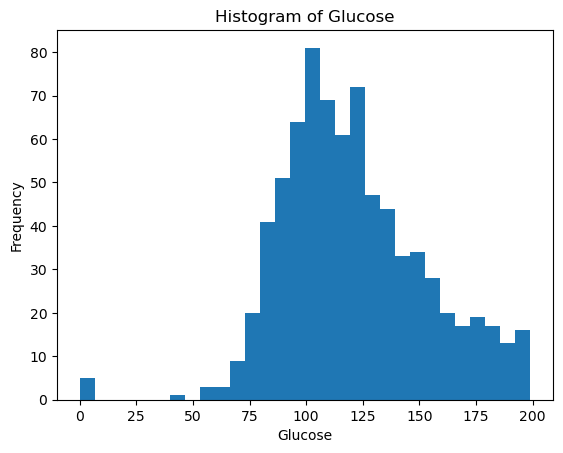

In [5]:
# Histogram of Glucose

plt.figure()
plt.hist(df['Glucose'].dropna(), bins=30)   # Histogram using 30 bins for detail
plt.title('Histogram of Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.show()

# Draw the histogram of 'Glucose values ignoring missing

### Right-skewed distribution: subset of patients with very high values.

## 2) Boxplot of BMI

C:\Users\lawra\AppData\Local\Temp\ipykernel_25316\339372408.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['BMI'].dropna(), vert=True, labels=['BMI'])


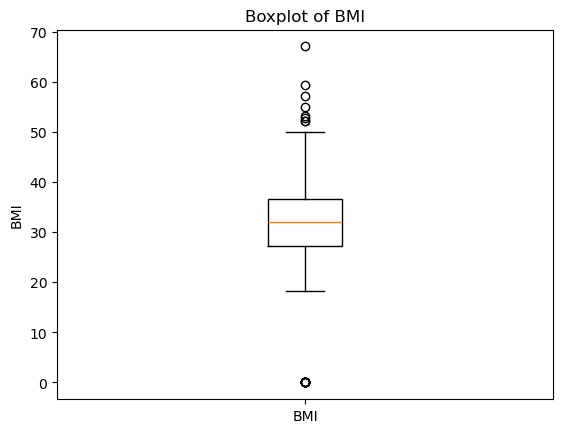

In [6]:
# Boxplot of BMI

plt.figure()
plt.boxplot(df['BMI'].dropna(), vert=True, labels=['BMI'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

# Boxplot summarize spread (IQR) and highlight outliers

### Median & IQR captured by the box; points beyond whiskers are outliers.

## 3) Scatter plot between two variables (i.e., glucose vs insulin)

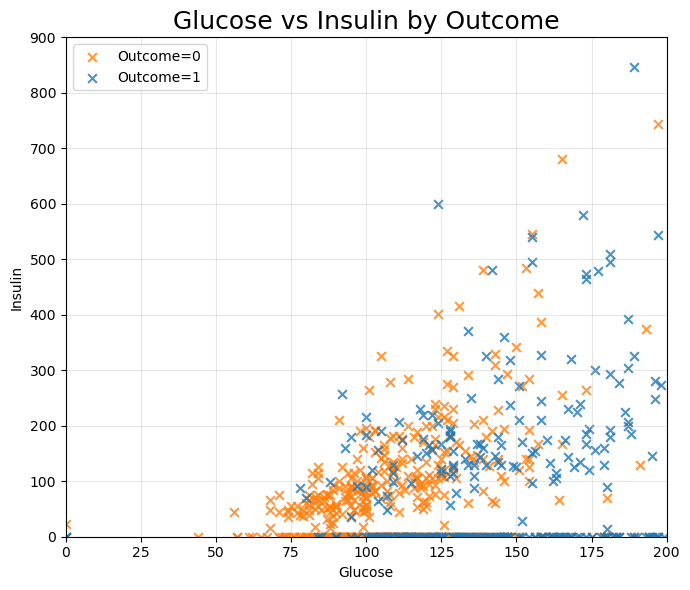

In [10]:
# Scatter: Glocuse vs Insulin

m0 = df["Outcome"] == 0
m1 = df["Outcome"] == 1

plt.figure(figsize=(7, 6))
plt.scatter(df.loc[m0, "Glucose"], df.loc[m0, "Insulin"],
            label="Outcome=0", marker="x", s=40, alpha=0.8, c="tab:orange")
plt.scatter(df.loc[m1, "Glucose"], df.loc[m1, "Insulin"],
            label="Outcome=1", marker="x", s=40, alpha=0.8, c="tab:blue")

plt.title("Glucose vs Insulin by Outcome", fontsize=18)
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.xlim(0, 200)
plt.ylim(0, 900)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# Scatter plots reveal potential relationship between two numeric variables

### Relationship check; zeros in insulin indicate potential missing/unreliable entries.

## 4) Scatter plot between another two variables (i.e., BMI vs SkinThickness)

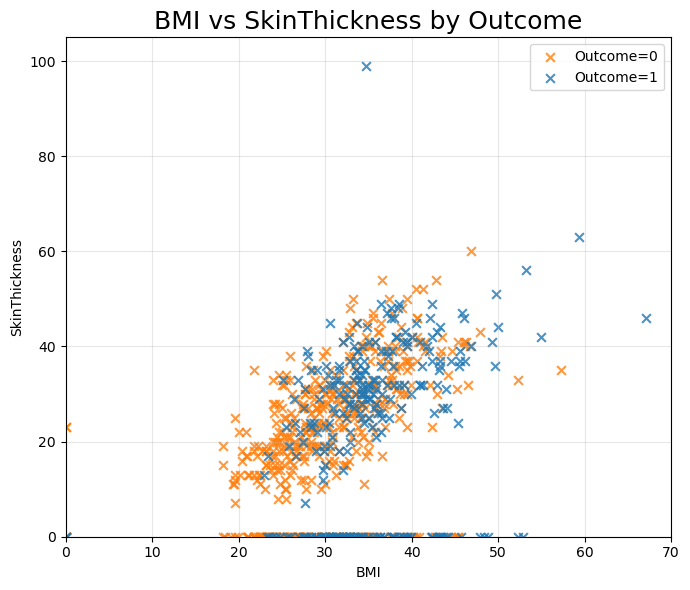

In [11]:
# Scatter: BMI vs SkinThickness

m0 = df["Outcome"] == 0
m1 = df["Outcome"] == 1

plt.figure(figsize=(7, 6))
plt.scatter(df.loc[m0, "BMI"], df.loc[m0, "SkinThickness"],
            label="Outcome=0", marker="x", s=40, alpha=0.8, c="tab:orange")
plt.scatter(df.loc[m1, "BMI"], df.loc[m1, "SkinThickness"],
            label="Outcome=1", marker="x", s=40, alpha=0.8, c="tab:blue")

plt.title("BMI vs SkinThickness by Outcome", fontsize=18)
plt.xlabel("BMI")
plt.ylabel("SkinThickness")
plt.xlim(0, 70)
plt.ylim(0, 105)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Moderate positive relationship: higher BMI tends to align with thicker skinfolds.

## 5) Count plot of the target variable (Outcome)

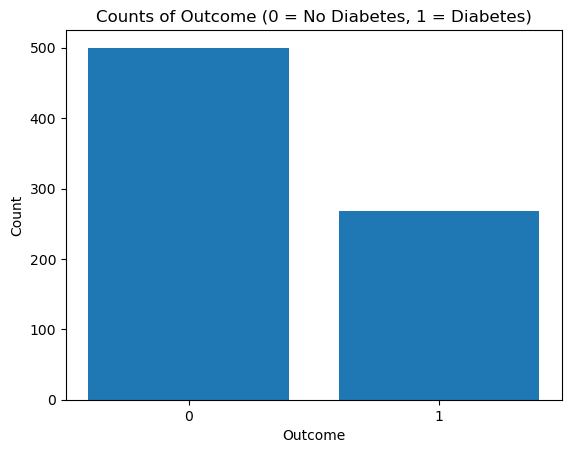

In [10]:
# Outcome counts (bar chart)

plt.figure()
counts = df['Outcome'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Counts of Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

### Class balance matters for modeling; more non-diabetic than diabetic cases.

## Part 3: Exploratory Data Analysis (EDA)

In [11]:
# I will select only numeric columns for statistical calculations

num_df = df.select_dtypes(include=[np.number])

mean_s = num_df.mean()
median_s = num_df.median()

# Rnage and IQR
range_s = num_df.max() - num_df.min()
q1 = num_df.quantile(0.25)
q3 = num_df.quantile(0.75)
iqr_s = q3 - q1

# Variance and Standard Deviation
var_s = num_df.var()
std_s = num_df.std()

# Covariance and Correlation Matrices
cov_m = num_df.cov()
corr_m = num_df.corr()

stats_table = pd.DataFrame({
    'Mean': mean_s,
    'Median': median_s,
    'Range': range_s,
    'IQR': iqr_s,
    'Standard Deviation': std_s
})
stats_table.round(3)

,Mean,Median,Range,IQR,Standard Deviation
Pregnancies,3.845,3.000,17.000,5.000,3.370
Glucose,120.895,117.000,199.000,41.250,31.973
BloodPressure,69.105,72.000,122.000,18.000,19.356
SkinThickness,20.536,23.000,99.000,32.000,15.952
Insulin,79.799,30.500,846.000,127.250,115.244
BMI,31.993,32.000,67.100,9.300,7.884
DiabetesPedigreeFunction,0.472,0.372,2.342,0.382,0.331
Age,33.241,29.000,60.000,17.000,11.760
Outcome,0.349,0.000,1.000,1.000,0.477


### 1. Mean: Average value across all records. For example, average glucose is ~121, suggesting mild hyperglycemia in the sample.

### 2. Median: Middle value when data is sorted. For Glucose (117) vs mean (121), values are slightly skewed right.

### 3. Range: Difference between max and min. Insulin has a huge range (846), reflecting extreme outliers and many zero entries.

### 4. IQR (Interquartile Range): Spread of the middle 50% of data. Insulin’s IQR = 127.25, much larger than other variables, again showing wide variability.

### 5. Variance & Standard Deviation: Variability measures. Larger Standard Deviation (e.g., Insulin = 115.24) means the data is highly spread out. Smaller ones (e.g., DPF = 0.33) mean tighter clustering.


## Part 4: Correlation Analysis

### 1) Plot a correlation heatmap of all variables.

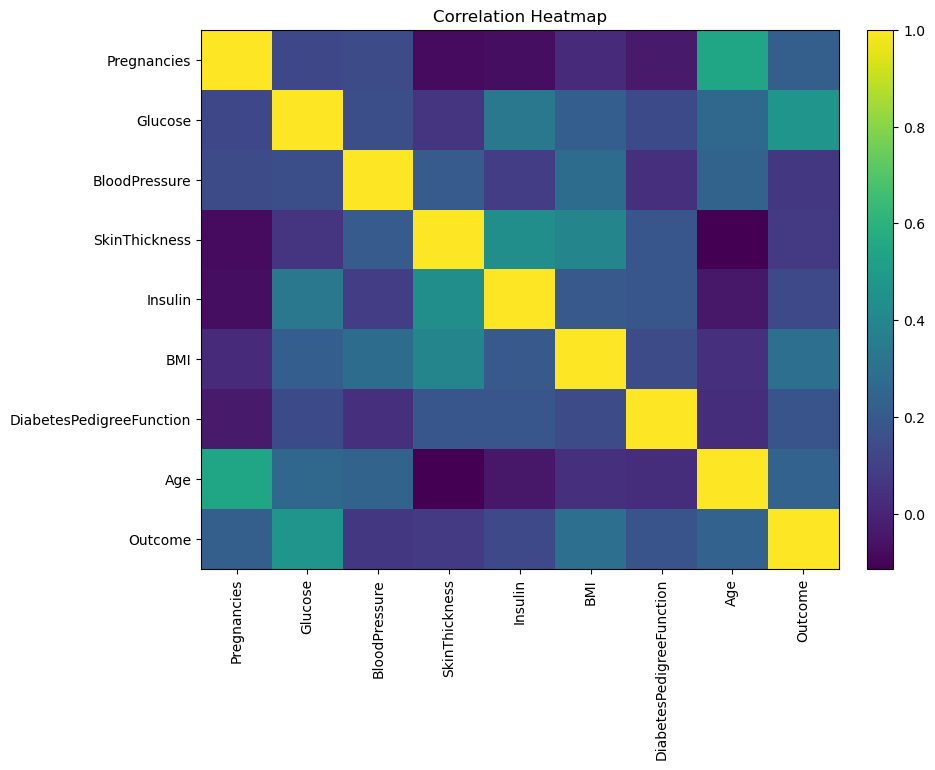

In [12]:
# Correlation of heatmap

corr = df.corr(numeric_only=True)
plt.figure(figsize=(9,7))
im = plt.imshow(corr, aspect='auto')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

### Glucose shows the strongest positive correlation with Outcome; others are weaker.

### 2) Plot a pairplot of the dataset.

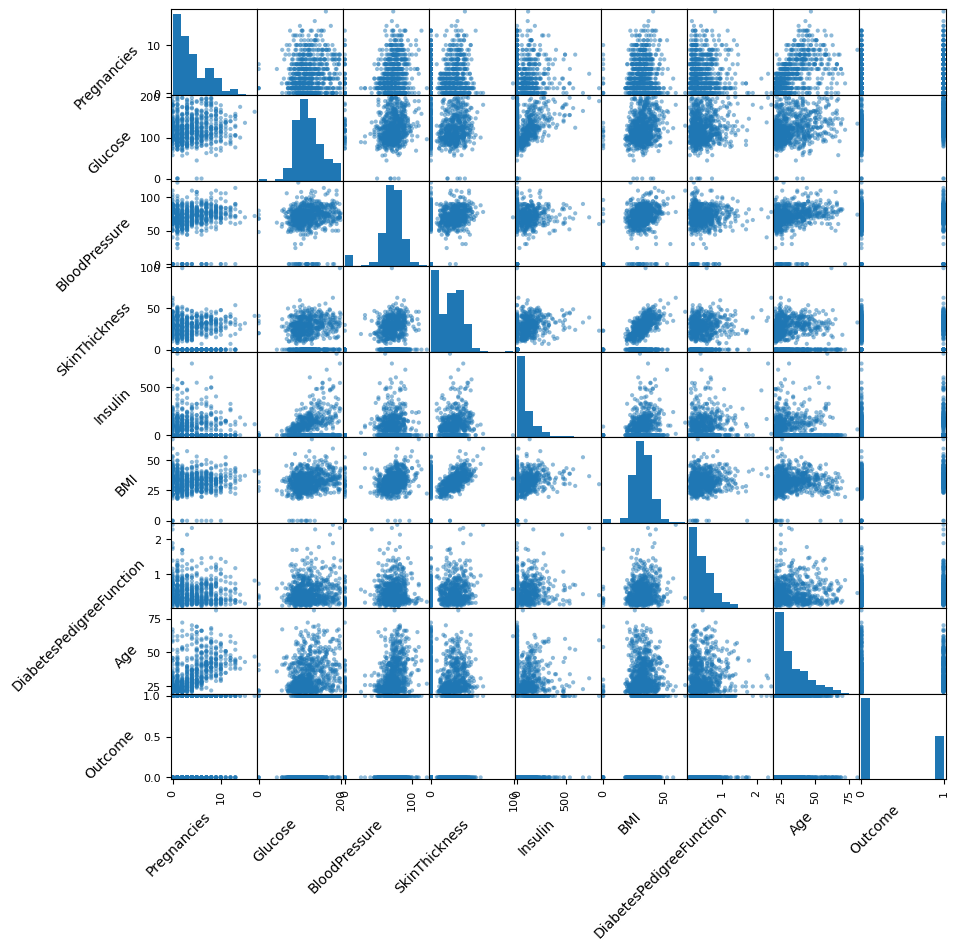

In [13]:
# Using the Pairwise Scatter Matrix (Pairplot Analog)

axs = scatter_matrix(df.select_dtypes(include=[np.number]), figsize=(10,10), diagonal='hist')
for ax in axs.ravel():
    ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')
plt.show()

### All pairs visualized at once; diagonals show distributions.

## Focused Comparisons: Glucose & Age; BMI & Diabetes

In [14]:
# Compare group means for key risk factor by outcome

group_means = df.groupby('Outcome')[['Glucose','Age','BMI','DiabetesPedigreeFunction']].mean().round(2)
group_means

,Glucose,Age,BMI,DiabetesPedigreeFunction
Outcome,,,,
0,109.98,31.19,30.30,0.43
1,141.26,37.07,35.14,0.55


C:\Users\lawra\AppData\Local\Temp\ipykernel_35212\2654892640.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['Glucose'].dropna(),


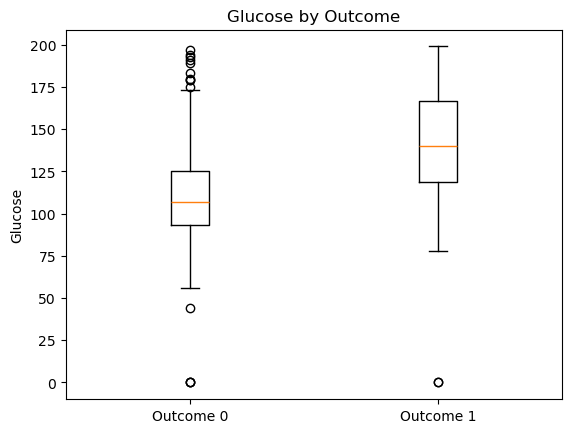

C:\Users\lawra\AppData\Local\Temp\ipykernel_35212\2654892640.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['Age'].dropna(),


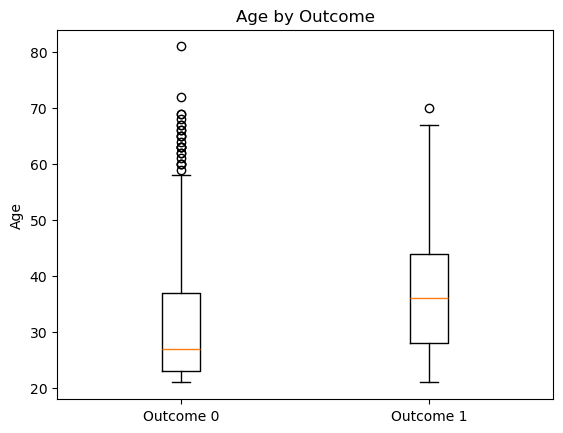

In [17]:
# Boxplots: Glucose and Age by Outcome

plt.figure()
plt.boxplot([df[df['Outcome']==0]['Glucose'].dropna(),
             df[df['Outcome']==1]['Glucose'].dropna()], labels=['Outcome 0', 'Outcome 1'])

plt.title('Glucose by Outcome')
plt.ylabel('Glucose')
plt.show()

plt.figure()
plt.boxplot([df[df['Outcome']==0]['Age'].dropna(),
             df[df['Outcome']==1]['Age'].dropna()], labels=['Outcome 0', 'Outcome 1'])

plt.title('Age by Outcome')
plt.ylabel('Age')
plt.show()

### Higher Glucose in Outcome-1 indicates strong association with diabetes.
### Higher Age in Outcome 1 suggests risk increases with age.

C:\Users\lawra\AppData\Local\Temp\ipykernel_35212\2073464276.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome']==0]['BMI'].dropna(),


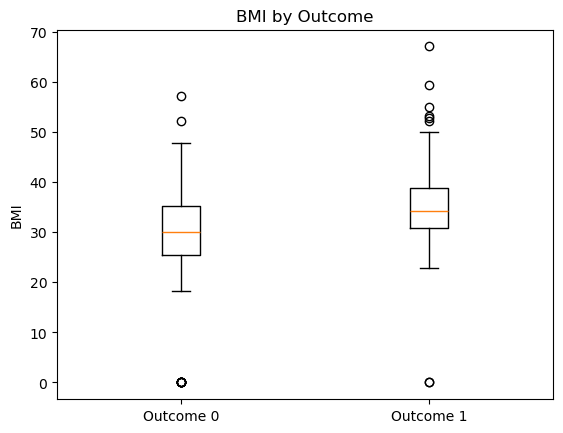

In [19]:
# Boxplot: BMI vs Outcome

plt.figure()
plt.boxplot([df[df['Outcome']==0]['BMI'].dropna(),
             df[df['Outcome']==1]['BMI'].dropna()], labels=['Outcome 0', 'Outcome 1'])

plt.title('BMI by Outcome')
plt.ylabel('BMI')
plt.show()

### Median BMI tends to be higher for Outcome=1, aligning with obesity as a risk factor.